<!-- # Task 1: Data Wrangling
# Objective:
# Clean and preprocess a given dataset by handling missing data, dealing with outliers, and transforming the data for further analysis.
# Dataset:
# Use the Seaborn Titanic dataset (seaborn.load_dataset("titanic")).
# Steps to Follow:
# 1. Data Loading:
#    Load the Titanic dataset using seaborn.load_dataset("titanic").
# 2. Missing Data Handling:
#    Identify and report the missing values in the dataset.
#    Fill the missing values:
#    For numerical columns (age, fare), impute using the median.
#    For categorical columns (embarked, deck), impute using the mode.
# 3. Outlier Detection:
#    Identify outliers in the age and fare columns using the IQR method (Interquartile Range).
#    Handle the outliers by either removing them or replacing them with the median of the column.
# 4. Feature Transformation:
#    Create a new feature family_size: Combine the sibsp and parch columns.
#    Create an age_group feature: Categorize passengers into "Child", "Adult", and "Senior" based on their age.
# 5. Categorical Data Encoding:
#    Convert the sex column into a numerical format using Label Encoding (1 for male, 0 for female).
# 6. Normalization:
#    Normalize the age and fare columns using MinMax scaling. -->

In [1]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [2]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

df['age'] = pd.to_numeric(df['age'])
age_median = df['age'].median()
df['age'].fillna(age_median, inplace=True)

df['fare'] = pd.to_numeric(df['fare'])
fare_median = df['fare'].median()
df['fare'].fillna(fare_median, inplace=True)

df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['deck'].fillna(df['deck'].mode()[0], inplace=True)

df[['age', 'fare', 'embarked', 'deck']].head(10)

Missing Values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_18012\1588929027.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(age_median, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18012\1588929027.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

,age,fare,embarked,deck
0,22.0,7.2500,S,C
1,38.0,71.2833,C,C
2,26.0,7.9250,S,C
3,35.0,53.1000,S,C
4,35.0,8.0500,S,C
5,28.0,8.4583,Q,C
6,54.0,51.8625,S,E
7,2.0,21.0750,S,C
8,27.0,11.1333,S,C
9,14.0,30.0708,C,C


In [7]:
df['family_size'] = df['sibsp'] + df['parch']

def categorize_age(age):
    if age < 15:
        return "Child"
    elif age < 50:
        return "Adult"
    else:
        return "Senior"

df['age_group'] = df['age'].apply(categorize_age)

df[['sibsp', 'parch', 'family_size', 'age', 'age_group']]


,sibsp,parch,family_size,age,age_group
0,1,0,1,22.0,Adult
1,1,0,1,38.0,Adult
2,0,0,0,26.0,Adult
3,1,0,1,35.0,Adult
4,0,0,0,35.0,Adult
...,...,...,...,...,...
886,0,0,0,27.0,Adult
887,0,0,0,19.0,Adult
888,1,2,3,28.0,Adult
889,0,0,0,26.0,Adult


In [8]:
df['sex'] = df['sex'].astype(str)  
df['sex'] = df['sex'].replace({'male': 1, 'female': 0})

df[['sex']]

C:\Users\Admin\AppData\Local\Temp\ipykernel_18012\3689618859.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'male': 1, 'female': 0})


,sex
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [9]:
df['age'] = (df['age'] - df['age'].min()) / (df['age'].max() - df['age'].min())
df['fare'] = (df['fare'] - df['fare'].min()) / (df['fare'].max() - df['fare'].min())

df[['age', 'fare']] 

,age,fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713
...,...,...
886,0.334004,0.025374
887,0.233476,0.058556
888,0.346569,0.045771
889,0.321438,0.058556


<!-- # Task 2: Exploratory Data Analysis (EDA)
# Objective:
# Perform an exploratory analysis on the Titanic dataset to derive insights and visualize patterns.
# Dataset:
# Use the Seaborn Titanic dataset.
# Steps to Follow:
# 1. Univariate Analysis:
#    Plot histograms for numerical features (age, fare, family_size).
#    Visualize the distribution of the survived column using a countplot.
# 2. Bivariate Analysis:
#    Create a boxplot to show the distribution of fare based on the class feature.
#    Create a violin plot to explore how age varies across different class values.
#    Plot the correlation matrix of numerical features using a heatmap.
# 3. Group-wise Analysis:
#    Group the data by the survived column and calculate the mean of age, fare, and family_size for both survivors and non-survivors.
#    Create a bar plot to show the average fare for survivors vs. non-survivors.
# 4. Multivariate Analysis:
#    Create a pairplot to visualize the relationships between age, fare, and family_size with survived as the hue.
#    Use a stacked bar plot to compare the survival rate across different class values and sex. -->


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


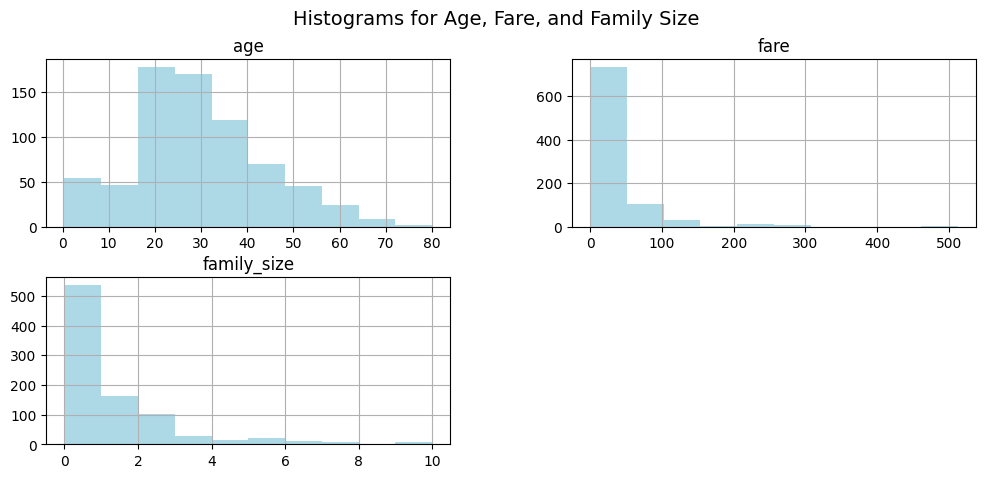

In [ ]:
df['family_size'] = df['sibsp'] + df['parch']  

df[['age', 'fare', 'family_size']].hist(bins=10, figsize=(12, 5), color='lightblue')
plt.suptitle("Histograms for Age, Fare and Family Size", fontsize=14)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_18012\2511281507.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['survived'], palette="coolwarm")


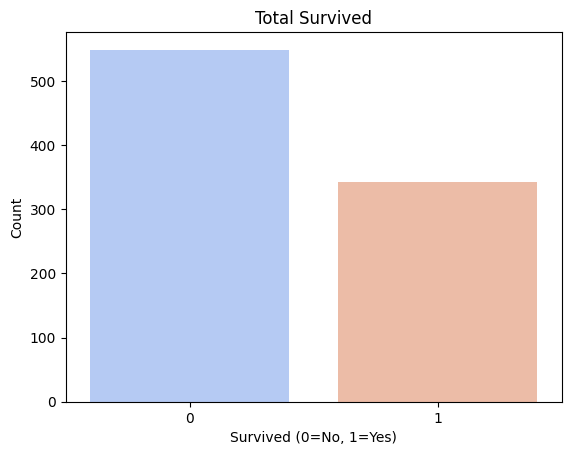

In [19]:
sns.countplot(x=df['survived'], palette="coolwarm")
plt.title("Total Survived")
plt.xlabel("Survived (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_18012\988642895.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['class'], y=df['fare'], palette="pastel")


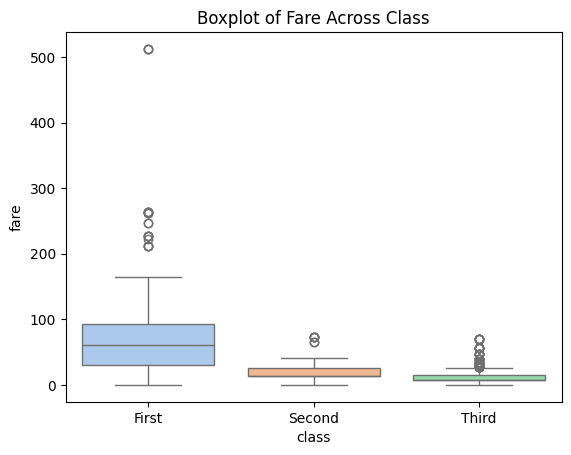

In [34]:
sns.boxplot(x=df['class'], y=df['fare'], palette="pastel")
plt.title("Boxplot of Fare Across Class")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_18012\336459241.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df['class'], y=df['age'], palette="pastel")


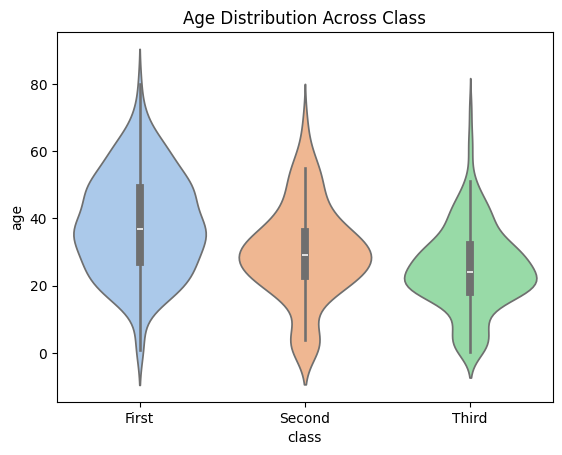

In [23]:
sns.violinplot(x=df['class'], y=df['age'], palette="pastel")
plt.title("Age Distribution Across Class")
plt.show()


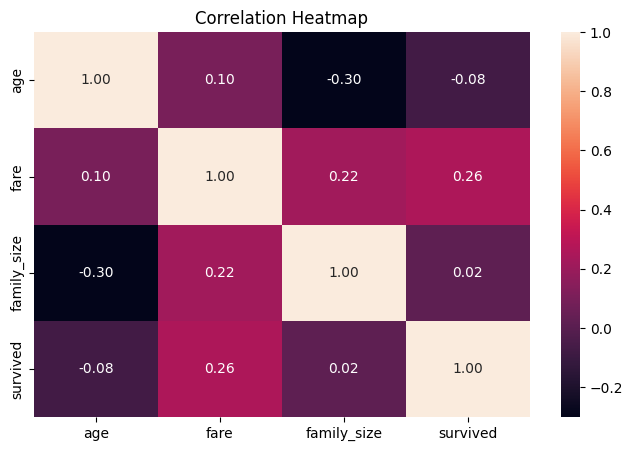

In [25]:
import numpy as np

plt.figure(figsize=(8, 5))
sns.heatmap(df[['age', 'fare', 'family_size', 'survived']].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [26]:
df.groupby('survived')[['age', 'fare', 'family_size']].mean()


,age,fare,family_size
survived,,,
0,30.626179,22.117887,0.883424
1,28.343690,48.395408,0.938596


C:\Users\Admin\AppData\Local\Temp\ipykernel_18012\1784295.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['survived'], y=df['fare'], palette="coolwarm")


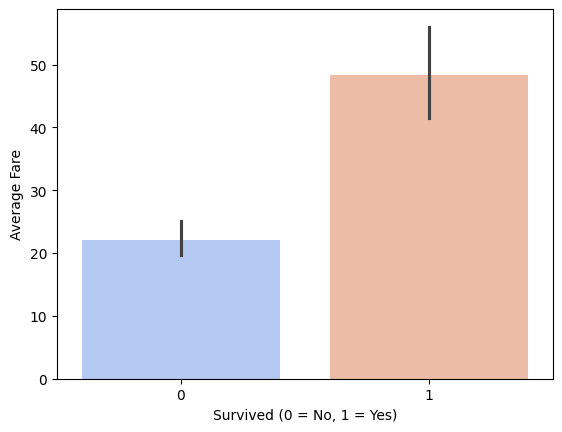

In [29]:
sns.barplot(x=df['survived'], y=df['fare'], palette="coolwarm")
plt.title("Average Fare by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Average Fare")
plt.show()


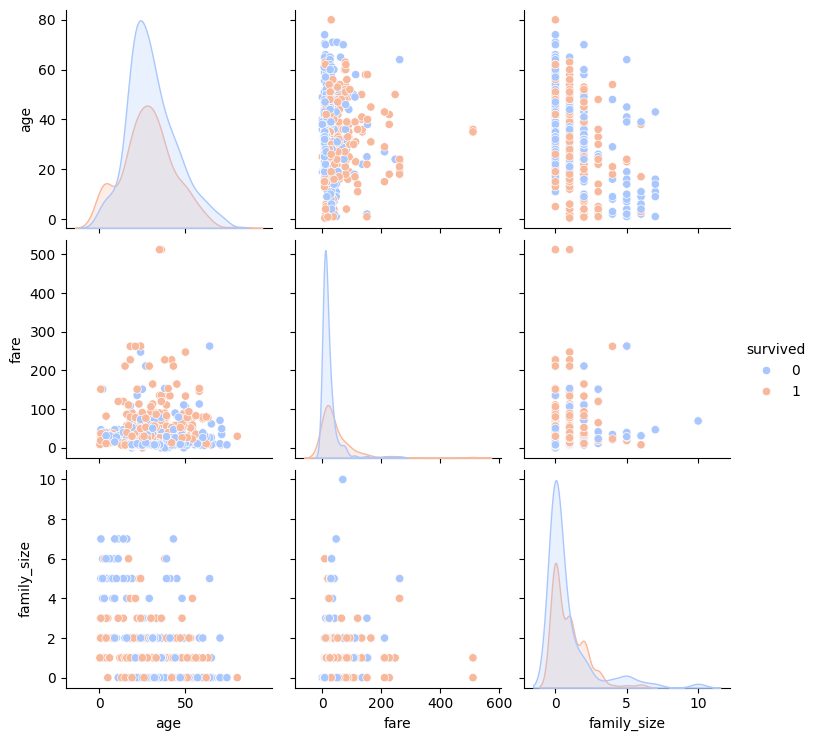

In [30]:
sns.pairplot(df, vars=['age', 'fare', 'family_size'], hue='survived', palette="coolwarm")
plt.show()
